 1. Загрузите картинку parrots.jpg. Преобразуйте изображение, приведя все значения в интервал от 0 до 1. Для этого можно воспользоваться функцией img_as_float из модуля skimage. Обратите внимание на этот шаг, так как при работе с исходным изображением вы получите некорректный результат.

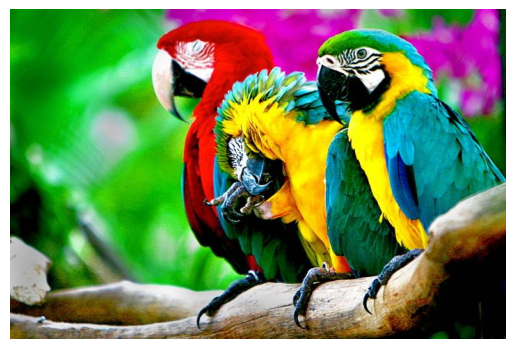

In [ ]:
from skimage.io import imread
from skimage import img_as_float
import matplotlib.pyplot as plt

image = imread('parrots.jpg')
image= img_as_float(image)  #приводим к диапазону 0,1

plt.imshow(image)
plt.axis('off')
plt.show()


2. Создайте матрицуобъекты-признаки: характеризуйте каждый пиксель тремя координатами- значениями интенсивности в пространстве RGB.

In [ ]:
import numpy as np

w, h, d =image.shape  #ширина, высота, каналы
X = image.reshape((w * h, d))


 3. Запустите алгоритм K-Means с параметрами init=’k-means++’ и random_state=241. После выделения кластеров все пиксели, отнесенные в один кластер, попробуйте заполнить двумя способами: медианным и средним цветом по кластеру.

In [ ]:
from sklearn.cluster import KMeans

def apply_kmeans(X, n_clusters, random_state=241):
    kmeans =KMeans(n_clusters=n_clusters, init='k-means++', random_state=random_state, n_init='auto')
    kmeans.fit(X)
    return kmeans.labels_, kmeans.cluster_centers_


In [ ]:
apply_kmeans(X, 10)

(array([3, 3, 3, ..., 4, 4, 8], dtype=int32),
 array([[0.45047371, 0.36902695, 0.15169779],
        [0.80158497, 0.8255773 , 0.80454509],
        [0.95418061, 0.82624128, 0.04403251],
        [0.09242742, 0.64820855, 0.05961582],
        [0.04752092, 0.08563803, 0.02483483],
        [0.04665314, 0.61563859, 0.67055461],
        [0.77613622, 0.09262056, 0.69071774],
        [0.79467675, 0.07269385, 0.02884049],
        [0.07083545, 0.36126746, 0.31130055],
        [0.45774568, 0.71855517, 0.48172686]]))

In [ ]:
def recolor_image(X, labels, centers, method):
    X_new = np.zeros_like(X)
    for i in range(centers.shape[0]):
        mask = labels== i
        if method == 'mean':
            color = X[mask].mean(axis=0)
        elif method == 'median':
            color = np.median(X[mask], axis=0)
        X_new[mask] = color
    return X_new

 4. Измерьте качество получившейся сегментации с помощью метрики PSNR. Эту метрику нужно реализовать самостоятельно (см. определение).

In [ ]:
def psnr(img1, img2):
    mse = ((img1 -img2) ** 2).mean()
    if mse== 0:
        return float('inf')
    return 20 *np.log10(1.0/ np.sqrt(mse))


 5. Найдите минимальное количество кластеров, при котором значение PSNR выше 20 (можно рассмотреть не более 20 кластеров, но не забудьте рассмотреть оба способа заполнения пикселей одного кластера). Это число и будет ответом в данной задаче.

In [ ]:
original_image = X.reshape(w, h, d)

for k in range(2, 21):
    labels, centers = apply_kmeans(X, k)

    mean_image = recolor_image(X, labels, centers, method='mean').reshape(w, h, d)
    median_image= recolor_image(X, labels, centers,method='median').reshape(w, h, d)

    psnr_mean = psnr(original_image, mean_image)
    psnr_median =psnr(original_image, median_image)

    print(f'Clusters: {k}, PSNR (mean): {psnr_mean:.2f}, PSNR (median): {psnr_median:.2f}')

    if psnr_mean > 20 or psnr_median > 20:
        print(f'Минимальное количество кластеров с PSNR > 20: {k}')
        break


Clusters: 2, PSNR (mean): 12.11, PSNR (median): 11.69
Clusters: 3, PSNR (mean): 13.17, PSNR (median): 12.63
Clusters: 4, PSNR (mean): 14.32, PSNR (median): 14.00
Clusters: 5, PSNR (mean): 15.09, PSNR (median): 14.69
Clusters: 6, PSNR (mean): 16.57, PSNR (median): 16.07
Clusters: 7, PSNR (mean): 17.67, PSNR (median): 17.37
Clusters: 8, PSNR (mean): 18.38, PSNR (median): 18.10
Clusters: 9, PSNR (mean): 19.14, PSNR (median): 18.84
Clusters: 10, PSNR (mean): 19.54, PSNR (median): 19.23
Clusters: 11, PSNR (mean): 20.08, PSNR (median): 19.83
Минимальное количество кластеров с PSNR > 20: 11
